In [1]:
import sys
from pathlib import Path
import numpy as np
import torch


project_root = Path.cwd().resolve().parents[1]
sys.path.append(str(project_root / "CODE" / "PaperCode"))

from factor_simulation import RiskFactorSimulator

In [2]:


# Example inputs
num_risk_factors = 3
initial_spot_values = [100.0, 95.0, 105.0]
drift_array = [0.03, 0.03, 0.03]
volatility_array = [0.20, 0.25, 0.18]
correl_matrix = [
    [1.0, 0.30, 0.10],
    [0.30, 1.0, 0.25],
    [0.10, 0.25, 1.0],
]
# Irregular time grid is allowed
time_steps = np.linspace(0,10,11)
num_sims = 1000

simulator = RiskFactorSimulator(
    num_risk_factors=num_risk_factors,
    initial_spot_values=initial_spot_values,
    drift_array = drift_array,
    volatility_array=volatility_array,
    correl_matrix=correl_matrix,
    time_steps=time_steps
)

paths = simulator.simulate_paths(num_sims=num_sims)

print("paths shape:", paths.shape)
print("first simulation path:\n", paths[0])
print("final values mean across simulations:\n", paths[:, -1, :].mean(dim=0))

paths shape: torch.Size([1000, 11, 3])
first simulation path:
 tensor([[100.0000,  95.0000, 105.0000],
        [116.7976, 103.4807, 153.6646],
        [109.0309, 136.4286, 157.5636],
        [157.0606, 185.4095, 214.0243],
        [152.2672, 248.8356, 240.3563],
        [123.7255, 191.9277, 235.8586],
        [125.7174, 285.7042, 315.9032],
        [119.3607, 280.8991, 237.9368],
        [136.9625, 218.6645, 223.4041],
        [161.4441, 255.5370, 221.8206],
        [130.2862, 229.1276, 204.1989]], dtype=torch.float64)
final values mean across simulations:
 tensor([137.0525, 123.2034, 142.0731], dtype=torch.float64)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plot_sims = min(100, paths.shape[0])
time_grid = simulator.time_steps.detach().cpu().numpy()
initial_values = si
num_factors = simulator.num_risk_factors

fig, axes = plt.subplots(num_factors, 1, figsize=(10, 3 * num_factors), sharex=True)
if num_factors == 1:
    axes = [axes]

for factor_idx, ax in enumerate(axes):
    factor_paths = paths[:plot_sims, :, factor_idx].detach().cpu().numpy()
    factor_with_initial = np.concatenate(
        [np.full((plot_sims, 1), initial_values[factor_idx]), factor_paths],
        axis=1,
    )

    for sim_idx in range(plot_sims):
        ax.plot(time_grid, factor_with_initial[sim_idx], alpha=0.35, linewidth=1, color = 'grey')

    ax.set_title(f"Risk factor {factor_idx + 1}")
    ax.set_ylabel("Value")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

NameError: name 'paths' is not defined

In [4]:
%time
# Run RiskFactorSimulator on Apple GPU (Metal Performance Shaders)
import torch

# Check if MPS is available
if torch.backends.mps.is_available():
    device = "mps"
    print("✓ Apple Metal GPU available, using MPS")
else:
    device = "cpu"
    print("⚠ Metal GPU not available, falling back to CPU")

device = "mps"

# Create simulator with explicit MPS device
simulator_gpu = RiskFactorSimulator(
    num_risk_factors=3,
    initial_spot_values=[100.0, 95.0, 105.0],
    drift_array=[0.03, 0.03, 0.03],
    volatility_array=[0.20, 0.25, 0.18],
    correl_matrix=[
        [1.0, 0.30, 0.10],
        [0.30, 1.0, 0.25],
        [0.10, 0.25, 1.0],
    ],
    time_steps=[0.1, 0.5, 1.0, 2.0, 5.0],
    device=device,
    dtype=torch.float32,
)

print(f"Simulator device: {simulator_gpu.device}")
print(f"Simulator dtype: {simulator_gpu.dtype}")

# Run simulation on GPU
paths_gpu = simulator_gpu.simulate_paths(num_sims=5000000)

print(f"\nSimulation results:")
print(f"Paths shape: {paths_gpu.shape}")
print(f"Paths device: {paths_gpu.device}")
print(f"Final mean values: {paths_gpu[:, -1, :].mean(dim=0)}")

CPU times: user 2 μs, sys: 1 μs, total: 3 μs
Wall time: 4.05 μs
✓ Apple Metal GPU available, using MPS
Simulator device: mps
Simulator dtype: torch.float32

Simulation results:
Paths shape: torch.Size([5000000, 5, 3])
Paths device: mps:0
Final mean values: tensor([116.1913, 110.3547, 121.9764], device='mps:0')
Final mean values: tensor([116.1913, 110.3547, 121.9764], device='mps:0')


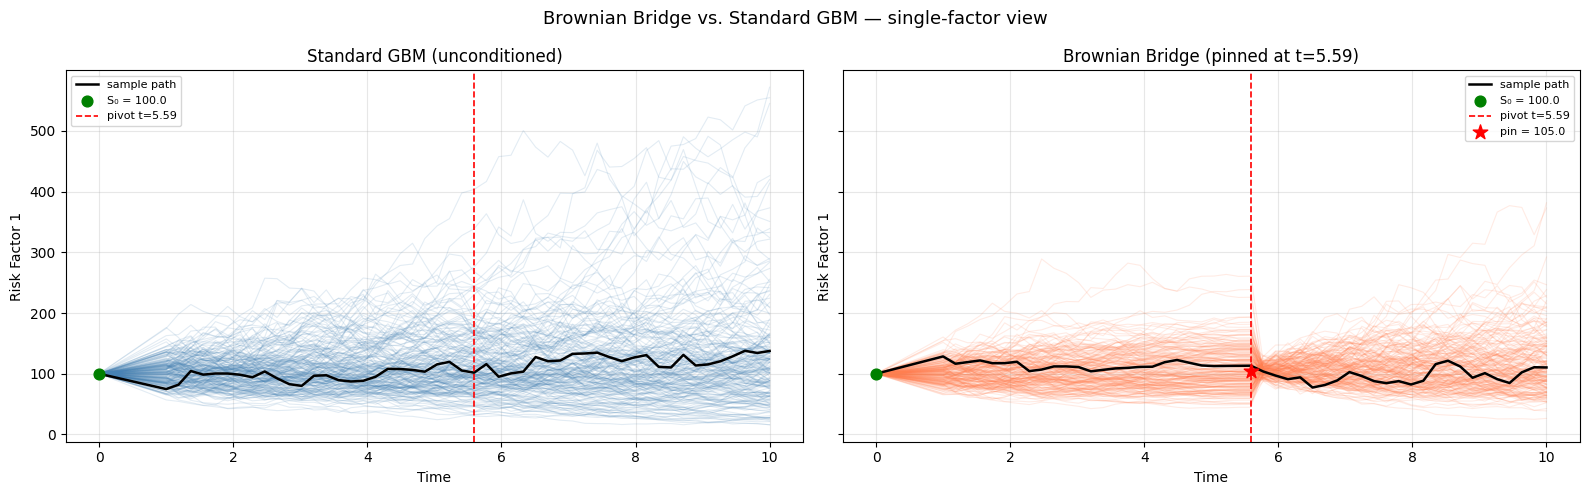

Max deviation at pivot (factor 1): 1.56e+02  (should be ≈ 0)


In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Simulation setup ──────────────────────────────────────────────────────────
# Use factor 0 only for a clean visual test.
# Pick the pivot at the middle of the time grid.
pivot_step_idx = len(simulator.time_steps) // 2       # e.g. step 25 of 50

t_grid = np.concatenate(([0.0], simulator.time_steps.cpu().numpy()))   # (51,)
t_pivot = t_grid[pivot_step_idx + 1]                                   # prepend-0 offset

# Observed (pinned) spot at pivot — use the same value for all simulations
# to make the pin easy to verify visually.
S0 = simulator.initial_spot_values.cpu().numpy()
spot_at_pivot = S0 * np.array([1.05, 0.98, 1.10])   # fixed pivot spots, shape (3,)

n_test_sims = 200
factor_to_plot = 0   # plot Risk Factor 1 only

# ── Run Brownian bridge simulation ────────────────────────────────────────────
paths_bridge = simulator.simulate_paths_with_bridge(
    num_sims=n_test_sims,
    pivot_step_idx=pivot_step_idx,
    spot_at_pivot=spot_at_pivot,
)
# paths_bridge: (n_test_sims, num_steps, num_risk_factors)

# Also run unconditioned simulation for comparison
paths_free = simulator.simulate_paths(num_sims=n_test_sims)

# ── Convert to numpy ──────────────────────────────────────────────────────────
f = factor_to_plot
S0_f = S0[f]
pivot_val = spot_at_pivot[f]

bridge_np = np.concatenate(
    [np.full((n_test_sims, 1), S0_f),
     paths_bridge[:, :, f].detach().cpu().numpy()],
    axis=1,
)
free_np = np.concatenate(
    [np.full((n_test_sims, 1), S0_f),
     paths_free[:, :, f].detach().cpu().numpy()],
    axis=1,
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, data, title, color in zip(
    axes,
    [free_np, bridge_np],
    ["Standard GBM (unconditioned)", f"Brownian Bridge (pinned at t={t_pivot:.2f})"],
    ["steelblue", "coral"],
):
    for i in range(n_test_sims):
        ax.plot(t_grid, data[i], alpha=0.15, linewidth=0.8, color=color)

    # Highlight one sample path
    ax.plot(t_grid, data[0], linewidth=1.8, color="black", label="sample path")

    # Mark S0 and pivot
    ax.scatter([0], [S0_f], zorder=5, s=60, color="green", label=f"S₀ = {S0_f:.1f}")
    ax.axvline(t_pivot, color="red", linestyle="--", linewidth=1.2, label=f"pivot t={t_pivot:.2f}")

    if "Bridge" in title:
        ax.scatter([t_pivot], [pivot_val], zorder=6, s=120,
                   marker="*", color="red", label=f"pin = {pivot_val:.1f}")

    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel(f"Risk Factor {f + 1}")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle("Brownian Bridge vs. Standard GBM — single-factor view", fontsize=13)
plt.tight_layout()
plt.show()

# ── Verify the pin: all bridge paths must pass through pivot_val at t_pivot ──
pin_values = paths_bridge[:, pivot_step_idx, f].detach().cpu().numpy()
max_err = np.abs(pin_values - pivot_val).max()
print(f"Max deviation at pivot (factor {f+1}): {max_err:.2e}  (should be ≈ 0)")

In [8]:
import numpy as np
import torch

# --- 1) Simulate WITHOUT Brownian bridge ---
n_eval_sims = 20000
paths_eval = simulator.simulate_paths(num_sims=n_eval_sims)  # (n_sims, n_steps, n_rf)

# --- 2) Build full price tensor including t=0 ---
S0_t = simulator.initial_spot_values.unsqueeze(0).unsqueeze(0)          # (1,1,n_rf)
S_full = torch.cat([S0_t.expand(n_eval_sims, -1, -1), paths_eval], dim=1)  # (n_sims, n_steps+1, n_rf)

# Time increments
_t = torch.cat([
    torch.zeros(1, dtype=simulator.dtype, device=simulator.device),
    simulator.time_steps,
])
dt = _t[1:] - _t[:-1]                                                    # (n_steps,)

# --- 3) Log returns and implied Brownian increments ---
# r_k = log(S_{t_k}/S_{t_{k-1}}) = (mu-0.5*sigma^2)dt + sigma*dW_k
log_ret = torch.log(S_full[:, 1:, :] / S_full[:, :-1, :])               # (n_sims, n_steps, n_rf)

mu = simulator.drift_array                                                # (n_rf,)
sigma = simulator.volatility_array                                        # (n_rf,)

drift_term = (mu - 0.5 * sigma**2).unsqueeze(0).unsqueeze(0) * dt.unsqueeze(0).unsqueeze(-1)

# Estimated dW from the simulated prices
dW_hat = (log_ret - drift_term) / sigma.unsqueeze(0).unsqueeze(0)         # (n_sims, n_steps, n_rf)

# --- 4) Sampled volatilities ---
# For each factor i:
#   E[dW_i^2] = dt  =>  sigma_hat_i = sqrt( E[(r-drift)^2 / dt] )
vol_hat = torch.sqrt(
    ((log_ret - drift_term) ** 2 / dt.unsqueeze(0).unsqueeze(-1)).mean(dim=(0, 1))
)                                                                          # (n_rf,)

# --- 5) Sampled correlations of Brownian shocks ---
# Standardize by sqrt(dt) so each shock should be N(0,1)
std_shocks = dW_hat / torch.sqrt(dt).unsqueeze(0).unsqueeze(-1)           # (n_sims, n_steps, n_rf)
X = std_shocks.reshape(-1, simulator.num_risk_factors)                    # (n_sims*n_steps, n_rf)

# torch.corrcoef expects variables in rows => transpose
corr_hat = torch.corrcoef(X.T)                                             # (n_rf, n_rf)

# --- 6) Print comparison ---
print("Input volatility:", sigma.detach().cpu().numpy())
print("Sampled volatility:", vol_hat.detach().cpu().numpy())
print("\nInput correlation matrix:\n", simulator.correl_matrix.detach().cpu().numpy())
print("\nSampled correlation matrix:\n", corr_hat.detach().cpu().numpy())

print("\nAbs error (vol):", (vol_hat - sigma).abs().detach().cpu().numpy())
print("Max abs error (corr):", (corr_hat - simulator.correl_matrix).abs().max().item())

Input volatility: [0.2  0.25 0.18]
Sampled volatility: [0.19974217 0.24988858 0.18015599]

Input correlation matrix:
 [[1.   0.3  0.1 ]
 [0.3  1.   0.25]
 [0.1  0.25 1.  ]]

Sampled correlation matrix:
 [[1.         0.29994805 0.09831259]
 [0.29994805 1.         0.24844041]
 [0.09831259 0.24844041 1.        ]]

Abs error (vol): [0.00025783 0.00011142 0.00015599]
Max abs error (corr): 0.0016874118844819874


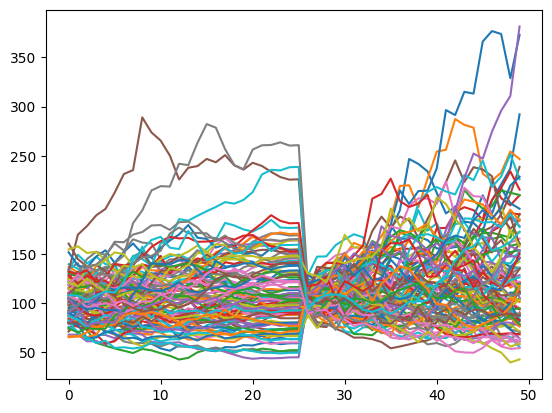

In [15]:
plt.plot(paths_bridge[0:100,:,0].cpu().detach().numpy().T)